Zakharov function:


\begin{equation}
\begin{array}{cl}
\displaystyle \min_{x \in \mathbb{R}^n} & \sum_{i=1}^{n} x_i^2 + \left( \frac{1}{2} \sum_{i=1}^{n} i x_i \right)^2 + \left( \frac{1}{2} \sum_{i=1}^{n} i x_i \right)^4
\end{array}
\end{equation}

In [8]:
# Load required packages
required_packages = ["DataFrames","LinearAlgebra","Statistics", "MAT","Random", "Plots","Zygote", "Measures", "PyPlot","Arpack"]
for pkg in required_packages
    try
        eval(Meta.parse("using $pkg"))
    catch e
        @warn "$pkg not found, installing..."
        import Pkg
        Pkg.add(pkg)
        eval(Meta.parse("using $pkg"))
    end
end

In [ ]:
#______________________________________________________________________________#
#             After switching to "Julia" kernel, run this cell                 #
#______________________________________________________________________________#
using DataFrames
using LinearAlgebra
using Statistics
using MAT
using Random
using Plots
using Zygote
using Measures
using PyPlot

#______________________________________________________________________________#
#                           --- Griewank function ---                            #
#______________________________________________________________________________#
Random.seed!(23)

# Define dimensions
n = 1000

# Zakharov function
function f(x)
    n = length(x)
    sum_x2 = sum(x[i]^2 for i in 1:n)
    weighted_sum = 0.5 * sum(i * x[i] for i in 1:n)
    term2 = weighted_sum^2
    term3 = weighted_sum^4
    return sum_x2 + term2 + term3
end

# Gradient via automatic differentiation
grad_f(x) = Zygote.gradient(f, x)[1]

# Generate a random initial point
x0 =  randn(n)

# Linear Minimization Oracle (LMO) unit l2 ball
function lmo(g; tau=1.0)
    norm_g = norm(g, 2)
    return norm_g > 0 ? -tau * g / norm_g : zeros(length(g))
end
#
rho =1
max_iter = 3000
#______________________________________________________________________________#

3000

In [ ]:
# Ensure all necessary packages are loaded   Norm 2
using DataFrames
using LinearAlgebra
using Statistics
using MAT
using Random
using Plots
using Zygote
using Measures
using PyPlot
using Arpack

#__________________________________Main Functions______________________________#
#______________________________________________________________________________#

#___________ __FW: Adaptive step-size with constant scalling___________________#
function conditional_gradient_adaptive(f, grad_f, lmo, x0, rho, max_iter, gamma; epsilon=1e-5, delta=1e-10, beta=2)
    println("\e[34m________Adaptive step-size: with constant scaling_________")
    x_prev = copy(x0)
    x_curr = copy(x0)
    values = [f(x_curr)]
    times = [0.0]
    gaps = Float64[]
    L_ks = Float64[]
    steps = Float64[]
    backtrack_counts = Int[]
    k = 0
    prev_grad = grad_f(x_prev)
    current_f = f(x_curr)
    prev_t_k = 0.0  # Initialize previous step size for k=0
    while k < max_iter
        start = time()
        current_grad = grad_f(x_curr)
        v = lmo(current_grad)
        grad_norm = norm(current_grad)
        if grad_norm <= epsilon
            println(">>>       Terminated at k=$k, Dual Gap: $(round(grad_norm, digits=4))")
            iteration_time = time() - start #  record final time
            push!(times, iteration_time)      #  save final time
            push!(gaps, grad_norm)
            break
        end
        if k == 0
            Random.seed!(23)
            d0 = randn(length(x0))
            L_k = gamma * ((norm(grad_f(x0) - grad_f(x0 + 1e-3 * d0)) / (1e-3 * norm(d0))) + delta)
        else
            grad_diff = norm(current_grad - prev_grad)
            L_k = gamma * (grad_diff / (rho * prev_t_k) + delta)  # Updated L_k using previous t_{k-1}
        end
        t_k = grad_norm / (rho * L_k)
        i = 0
        while true
            x_new = x_curr + t_k * v
            new_f = f(x_new)
            if current_f - new_f >= rho * t_k * grad_norm - (L_k / 2) * t_k^2 * rho^2
                x_prev = copy(x_curr)
                x_curr = x_new
                push!(backtrack_counts, i)
                break
            else
                L_k *= beta
                t_k = grad_norm / (rho * L_k)
                i += 1
            end
        end
        iteration_time = time() - start
        k += 1
        current_f = f(x_curr)
        prev_grad = current_grad
        prev_t_k = t_k  # Store current t_k for use in next iteration
        push!(gaps, grad_norm)
        push!(steps, t_k)
        push!(values, current_f)
        push!(times, iteration_time)
        push!(L_ks, L_k)
        if k % 100 == 0   # Print progress only every 100 iterations
            println("k $k: Dual Gap = $(round(grad_norm, digits=4)), t_k = $(round(t_k, digits=6)), L_k = $(round(L_k, digits=6)), Time = $(round(iteration_time, digits=4)) sec, f_k = $(round(current_f, digits=6))")
        end
    end
    println("k $k: Dual Gap = $(round(gaps[end], digits=4)), t_k = $(round(steps[end], digits=6)), L_k = $(round(L_ks[end], digits=6)), Time = $(round(times[end], digits=4)) sec, f_k = $(round(values[end], digits=6))")
    total_time = sum(times)
    println("Adaptive Method (γ=$gamma):")
    println("Total time: $(round(total_time, digits=4)) seconds")
    println("Total backtracking steps: $(sum(backtrack_counts))")
    println("Total iterations: $k")
    println("Objective value: $(round(current_f, digits=6))")
    println("Max L_k: $(round(maximum(L_ks), digits=6))")
    println("Mean L_k: $(round(mean(L_ks), digits=6))")
    println("____________________________________________________________\e[0m")
    return (x_curr, values, times, gaps, L_ks, backtrack_counts, steps)
end
#______________________________________________________________________________#
#____________FW: Adaptive step-size with adjustable scalling___________________#
function conditional_gradient_adjustable_scaling(f, grad_f, lmo, x0, rho, max_iter, gamma; epsilon=1e-5, delta=1e-10, beta=2)
    println("\e[33m_____________________Adaptive step-size with adjustable scalling_____________________")
    x_prev = copy(x0)
    x_curr = copy(x0)
    values = [f(x_curr)]
    times = [0.0]
    gaps = Float64[]
    L_ks = Float64[]
    steps = Float64[]
    backtrack_counts = Int[]
    gamma_history = [gamma]  # Track gamma over iterations
    k = 0
    prev_grad = grad_f(x_prev)
    current_f = f(x_curr)
    recent_backtracks = Int[]  # Store backtracking counts for the last 10 iterations
    prev_t_k = 0.0  # Initialize previous step size for k=0

    while k < max_iter
        start = time()
        current_grad = grad_f(x_curr)
        v = lmo(current_grad)
        grad_norm = norm(current_grad)
        if grad_norm <= epsilon
            println(">>>       Terminated at k=$k, Dual Gap: $(round(grad_norm, digits=4))")
            iteration_time = time() - start #  record final time
            push!(times, iteration_time)      #  save final time
            push!(gaps, grad_norm)
            break
        end
        if k == 0
            Random.seed!(23)
            d0 = randn(length(x0))
            L_k = gamma * ((norm(grad_f(x0) - grad_f(x0 + 1e-3 * d0)) / (1e-3 * norm(d0))) + delta)
        else
            grad_diff = norm(current_grad - prev_grad)
            L_k = gamma * (grad_diff / (rho * prev_t_k) + delta)  # Updated L_k using previous t_{k-1}
        end
        t_k = grad_norm / (rho * L_k)
        i = 0
        while true
            x_new = x_curr + t_k * v
            new_f = f(x_new)
            if current_f - new_f >= rho * t_k * grad_norm - (L_k / 2) * t_k^2 * rho^2
                x_prev = copy(x_curr)
                x_curr = x_new
                push!(backtrack_counts, i)
                push!(recent_backtracks, i)
                break
            else
                L_k *= beta
                t_k = grad_norm / (rho * L_k)
                i += 1
            end
        end
        iteration_time = time() - start
        k += 1
        current_f = f(x_curr)
        prev_grad = current_grad
        prev_t_k = t_k  # Store current t_k for use in next iteration
        push!(gaps, grad_norm)
        push!(steps, t_k)
        push!(values, current_f)
        push!(times, iteration_time)
        push!(L_ks, L_k)

        # Adaptive gamma adjustment every 10 iterations
        if k % 10 == 0 && k > 0
            total_backtracks = sum(recent_backtracks)
            if total_backtracks == 0
                gamma = gamma * 0.9  # Decrease gamma, with a lower bound
            elseif total_backtracks > 10
                gamma = min(1, gamma * 1.1)  # Increase gamma, with an upper bound
            end
            push!(gamma_history, gamma)
            recent_backtracks = Int[]  # Reset for the next 10 iterations
        elseif k % 10 == 0
            push!(gamma_history, gamma)
            recent_backtracks = Int[]
        else
            push!(recent_backtracks, i)
        end

        if k % 100 == 0
            println("k $k: Dual Gap = $(round(grad_norm, digits=4)), t_k = $(round(t_k,

 digits=6)), L_k = $(round(L_k, digits=6)), Time = $(round(iteration_time, digits=4)) sec, f_k = $(round(current_f, digits=6))")
        end
    end
    println("k $k: Dual Gap = $(round(gaps[end], digits=4)), t_k = $(round(steps[end], digits=6)), L_k = $(round(L_ks[end], digits=6)), Time = $(round(times[end], digits=4)) sec, f_k = $(round(values[end], digits=6))")
    total_time = sum(times)
    println("Adaptive Method (final γ=$(round(gamma, digits=4))):")
    println("Total time: $(round(total_time, digits=4)) seconds")
    println("Total backtracking steps: $(sum(backtrack_counts))")
    println("Total iterations: $k")
    println("Objective value: $(round(current_f, digits=6))")
    println("Max L_k: $(round(maximum(L_ks), digits=6))")
    println("Mean L_k: $(round(mean(L_ks), digits=6))")
    println("____________________________________________________________\e[0m")
    return (x_curr, values, times, gaps, L_ks, backtrack_counts, steps, gamma_history)
end
#______________________________________________________________________________#
#___________________________FW: Pedregosa et al. step-size_____________________#
function conditional_gradient_Pedregosa(f, grad_f, lmo, x0, rho, max_iter; epsilon=1e-5)
    println("\e[31m_____________________Pedregosa et al. step-size_____________")
    x_prev = copy(x0)
    values = [f(x_prev)]
    times = [0.0]
    gaps = Float64[]
    L_ks = Float64[]
    steps = Float64[]
    backtrack_counts = Int[]
    k = 0
    tau = 2.0
    eta = 0.9
    Random.seed!(23)
    d0 = randn(length(x0))
    L_minus1 = norm(grad_f(x0) - grad_f(x0 + 1e-3 * d0)) / (1e-3 * norm(d0))
    M = L_minus1 * eta
    while k < max_iter
        start = time()
        grad = grad_f(x_prev)
        v = lmo(grad)
        grad_norm=norm(grad)
        f_prev = f(x_prev)
        if grad_norm <= epsilon
            println(">>>       Terminated at k=$k, Dual Gap: $(round(grad_norm, digits=4))")
            iteration_time = time() - start #  record final time
            push!(times, iteration_time)      #  save final time
            push!(gaps, grad_norm)
            break
        end
        t_k = min(grad_norm / (M * rho), Inf)
        i = 0
        x_new = x_prev
        while true
            x_new = x_prev + t_k * v
            f_new = f(x_new)
            if f_prev - f_new >= rho * t_k * grad_norm - (M / 2) * t_k^2 * rho^2
                push!(backtrack_counts, i)
                break
            else
                M *= tau
                t_k = min(grad_norm / (M * rho), Inf)
                i += 1
            end
        end
        x_prev = x_new
        k += 1
        iteration_time = time() - start
        push!(values, f(x_new))
        push!(gaps, grad_norm)
        push!(times, iteration_time)
        push!(L_ks, M)
         push!(steps, t_k)
        if k % 100 == 0   # Print progress only every 100 iterations
            println("k $k: Dual Gap = $(round(grad_norm, digits=4)), t_k = $(round(t_k, digits=6)), M = $(round(M, digits=6)), Time = $(round(iteration_time, digits=4)) sec, f_k = $(round(f(x_new), digits=4))")
        end
        M = M * eta
    end
    println("k $k: Dual Gap = $(round(gaps[end], digits=4)), t_k = $(round(steps[end], digits=6)), L_k = $(round(L_ks[end], digits=6)), Time = $(round(times[end], digits=4)) sec, f_k = $(round(values[end], digits=6))")
    total_time = sum(times)
    println("Pedregosa Method:")
    println("Total time: $(round(total_time, digits=4)) seconds")
    println("Total backtracking steps: $(sum(backtrack_counts))")
    println("Total iterations: $k")
    println("Objective value: $(round(f(x_prev), digits=6))")
    println("Max L_k: $(round(maximum(L_ks), digits=4))")
    println("Mean L_k: $(round(mean(L_ks), digits=4))")
    println("____________________________________________________________\e[0m")
    return (x_prev, values, times, gaps, L_ks, backtrack_counts, steps)
end

#______________________________________________________________________________#


conditional_gradient_Pedregosa (generic function with 1 method)

In [ ]:
# Ensure all necessary packages are loaded
using DataFrames
using LinearAlgebra
using Statistics
using MAT
using Random
using Plots
using Zygote
using Measures
using PyPlot
using Arpack

#______________________________________________________________________________#
pyplot()
PyPlot.PyCall.pyimport("warnings").filterwarnings("ignore")
output_dir = "/content/output"  # Changed to distinguish from logistic output
mkpath(output_dir)
#____________________________________Run_______________________________________#
# --- Run and Plot (Adapted for Least_Squares_Radom) ---
results_our = conditional_gradient_adaptive(f, grad_f, lmo, x0, rho, max_iter, 1/4)
MAT.matwrite(joinpath(output_dir, "results_FW_OUR.mat"), Dict(
    "x" => results_our[1], "values" => results_our[2], "times" => results_our[3],
    "gaps" => results_our[4], "L_ks" => results_our[5], "backtrack_counts" => results_our[6],
    "steps" => results_our[7]
))
println("Saved: ", joinpath(output_dir, "results_FW_OUR.mat"))
#____________
results_our5 = conditional_gradient_adjustable_scaling(f, grad_f, lmo, x0, rho, max_iter, 1/4)
MAT.matwrite(joinpath(output_dir, "results_FW_OUR_5.mat"), Dict(
    "x" => results_our5[1], "values" => results_our5[2], "times" => results_our5[3],
    "gaps" => results_our5[4], "L_ks" => results_our5[5], "backtrack_counts" => results_our5[6],
    "steps" => results_our5[7]
))
println("Saved: ", joinpath(output_dir, "results_FW_OUR_5.mat"))
#____________
results_ped = conditional_gradient_Pedregosa(f, grad_f, lmo, x0, rho, max_iter)
MAT.matwrite(joinpath(output_dir, "results_FW_Pedregosa.mat"), Dict(
    "x" => results_ped[1], "values" => results_ped[2], "times" => results_ped[3],
    "gaps" => results_ped[4], "L_ks" => results_ped[5], "backtrack_counts" => results_ped[6],
    "steps" => results_ped[7]
))
println("Saved: ", joinpath(output_dir, "results_FW_Pedregosa.mat"))
#____________

#______________________________________________________________________________#
our = matread(joinpath(output_dir, "results_FW_OUR.mat"))
our5 = matread(joinpath(output_dir, "results_FW_OUR_5.mat"))
ped = matread(joinpath(output_dir, "results_FW_Pedregosa.mat"))
#______________________________________________________________________________#
# Define the output file for the table
println("\n# Summary of Results:   Norm 2")
println("Method             | Iterations | Time     | Objective | Gap      | Backtracking | Max L_k   | Mean L_k")
println("-------------------|------------|----------|-----------|----------|--------------|-----------|---------")
println("Adaptive constant  | $(length(our["values"]) - 1) | $(round(sum(our["times"]), digits=4)) | $(round(our["values"][end], digits=6)) | $(round(our["gaps"][end], digits=4)) | $(sum(our["backtrack_counts"])) | $(round(maximum(our["L_ks"]), digits=6)) | $(round(mean(our["L_ks"]), digits=6))")
println("Adaptive adjustable| $(length(our5["values"]) - 1) | $(round(sum(our5["times"]), digits=4)) | $(round(our5["values"][end], digits=6)) | $(round(our5["gaps"][end], digits=4)) | $(sum(our5["backtrack_counts"])) | $(round(maximum(our5["L_ks"]), digits=6)) | $(round(mean(our5["L_ks"]), digits=6))")
println("Pedregosa et al.   | $(length(ped["values"]) - 1) | $(round(sum(ped["times"]), digits=4)) | $(round(ped["values"][end], digits=6)) | $(round(ped["gaps"][end], digits=4)) | $(sum(ped["backtrack_counts"])) | $(round(maximum(ped["L_ks"]), digits=6)) | $(round(mean(ped["L_ks"]), digits=6))")
#______________________________________________________________________________#
# Print confirmation to console
println("All computations and plotting complete. Check $output_dir for results.")

________Adaptive step-size: with constant scaling_________
k 100: Dual Gap = 98.0518, t_k = 1.0e-6, L_k = 9.9508660102996e7, Time = 0.0121 sec, f_k = 1044.814238
k 200: Dual Gap = 65.1102, t_k = 2.0e-6, L_k = 3.1354827602959e7, Time = 0.0328 sec, f_k = 1044.803768
k 300: Dual Gap = 64.6932, t_k = 0.00012, L_k = 537600.569442, Time = 0.0201 sec, f_k = 1044.633078
k 400: Dual Gap = 65.4933, t_k = 2.0e-6, L_k = 3.2517470578824e7, Time = 0.0131 sec, f_k = 1044.381317
k 500: Dual Gap = 266.2772, t_k = 2.0e-6, L_k = 1.67428197219343e8, Time = 0.0121 sec, f_k = 1044.273767
k 600: Dual Gap = 66.0393, t_k = 8.0e-6, L_k = 8.759577441397e6, Time = 0.0125 sec, f_k = 1044.236642
k 700: Dual Gap = 65.4112, t_k = 9.0e-6, L_k = 6.90309725919e6, Time = 0.0224 sec, f_k = 1044.081975
k 800: Dual Gap = 74.0379, t_k = 2.0e-6, L_k = 4.4603706581893e7, Time = 0.0125 sec, f_k = 1044.055171
k 900: Dual Gap = 150.4696, t_k = 1.0e-6, L_k = 1.65784703664808e8, Time = 0.0125 sec, f_k = 1044.041329
k 1000: Dual Gap


# Summary of Results:

Method               Iterations    Time (s)   Objective    Gradient norm
───────────────────  ──────────  ──────────  ───────────  ──────────────
Adaptive constant          3000       46.27    1041.8932     112.3444
Adaptive adjustable        3000       45.73    1039.4353      64.5807
Pure backtracking          3000       44.71    1044.6405      64.6425

All computations and plotting complete. Check /content for results.
✅ Saved: Zakharov_L.eps


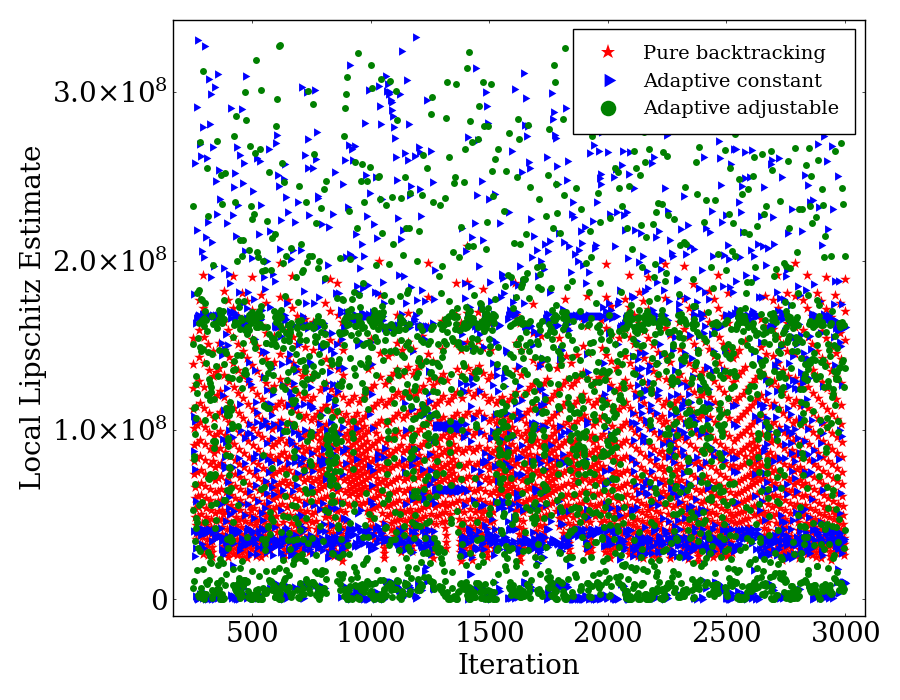

✅ Saved: Zakharov_Gap.eps


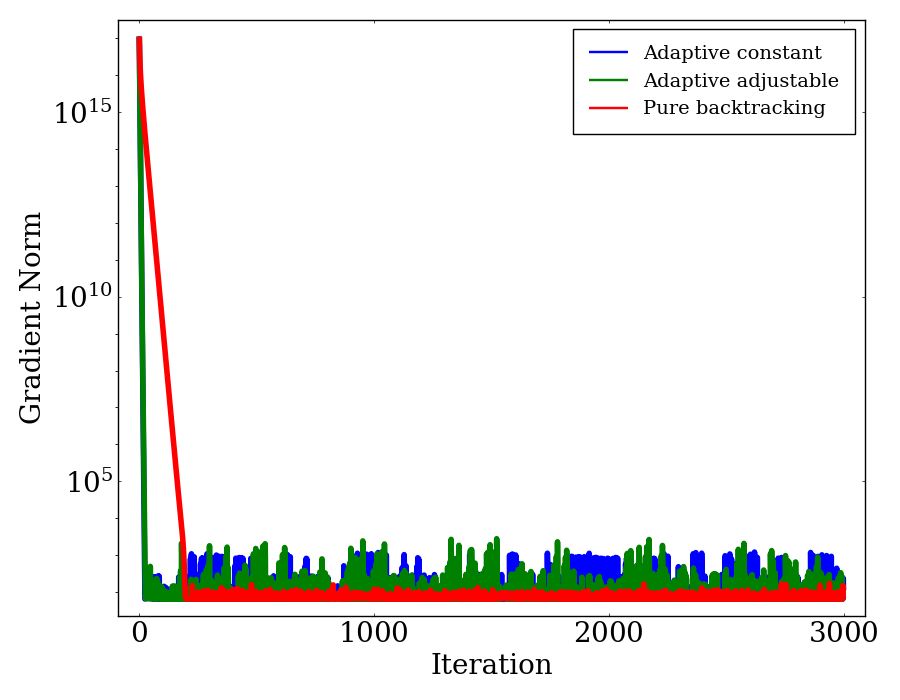

✅ Saved: Zakharov_Gap_vs_time.eps


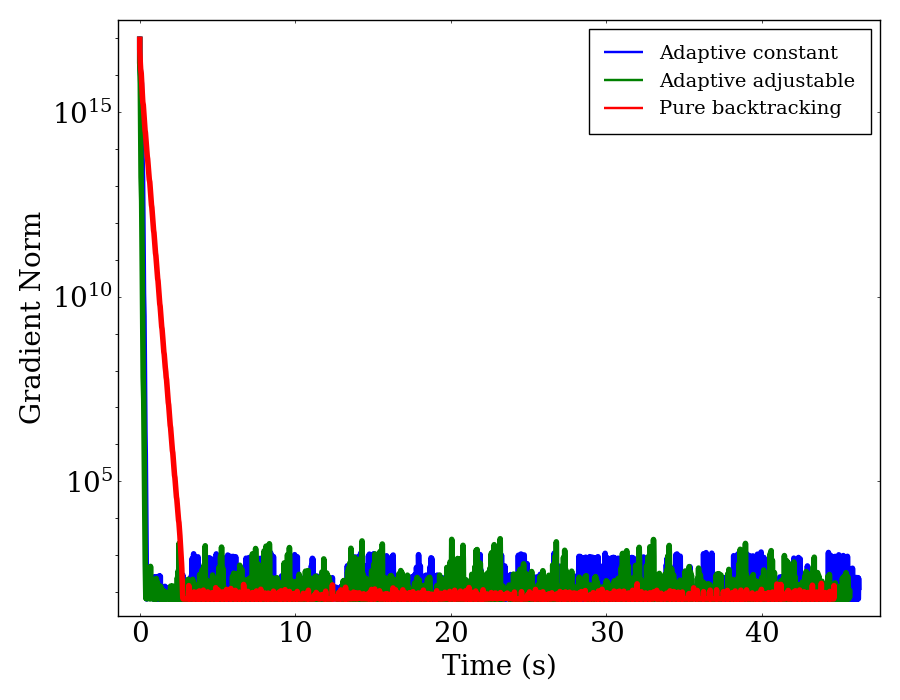


🎉 All plots saved as EPS in: /content


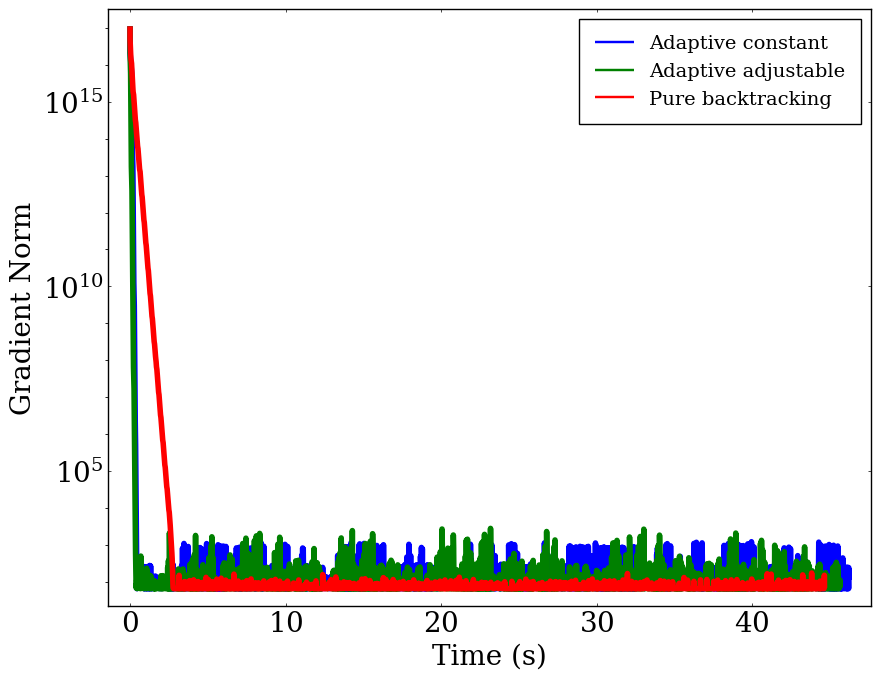

In [10]:
# Ensure all necessary packages are loaded
using DataFrames
using LinearAlgebra
using Statistics
using MAT
using Random
using Plots
using Zygote
using Measures
using PyPlot
using Arpack
using SparseArrays
#______________________________________________________________________________#
pyplot()
PyPlot.PyCall.pyimport("warnings").filterwarnings("ignore")
output_dir = "/content/output"  #


# --- LOAD DATA ONCE ---
our = matread(joinpath(output_dir, "results_FW_OUR.mat"))
our5 = matread(joinpath(output_dir, "results_FW_OUR_5.mat"))
ped = matread(joinpath(output_dir, "results_FW_Pedregosa.mat"))

# --- PRINT SUMMARY TABLE ---
println("\n# Summary of Results:\n")
println("Method               Iterations    Time (s)   Objective    Gradient norm")
println("───────────────────  ──────────  ──────────  ───────────  ──────────────")
# Adaptive constant
iter_our = length(our["values"]) - 1
time_our = round(sum(our["times"]), digits=2)
obj_our  = round(our["values"][end], digits=4)
gap_our  = round(our["gaps"][end], digits=4)
println(rpad("Adaptive constant", 20), lpad(iter_our, 11), "  ", lpad(time_our, 10), "  ", lpad(obj_our, 11), "  ", lpad(gap_our, 11))
# Adaptive adjustable
iter_our5 = length(our5["values"]) - 1
time_our5 = round(sum(our5["times"]), digits=2)
obj_our5  = round(our5["values"][end], digits=4)
gap_our5  = round(our5["gaps"][end], digits=4)
println(rpad("Adaptive adjustable", 20), lpad(iter_our5, 11), "  ", lpad(time_our5, 10), "  ", lpad(obj_our5, 11), "  ", lpad(gap_our5, 11))
# Pure backtracking
iter_ped = length(ped["values"]) - 1
time_ped = round(sum(ped["times"]), digits=2)
obj_ped  = round(ped["values"][end], digits=4)
gap_ped  = round(ped["gaps"][end], digits=4)
println(rpad("Pure backtracking", 20), lpad(iter_ped, 11), "  ", lpad(time_ped, 10), "  ", lpad(obj_ped, 11), "  ", lpad(gap_ped, 11))
println("\nAll computations and plotting complete. Check $output_dir for results.")


#________________________ PLOTTING FUNCTION (LEGEND ORDER = TABLE ORDER) ________________________#
function create_and_save_plots()
    # --- PREPARE CUMULATIVE TIMES ---
    our_cum_times = [0.0; cumsum(our["times"][1:end-1])]
    our5_cum_times = [0.0; cumsum(our5["times"][1:end-1])]
    ped_cum_times = [0.0; cumsum(ped["times"][1:end-1])]

    # --- STYLE DICTIONARY ---
    style = Dict(
        :titlefont => (20, "serif"),
        :guidefont => (20, "serif"),
        :tickfont => (20, "serif"),
        :legendfont => (14, "serif"),
        :grid => false,
        :framestyle => :box,
        :margin => 5mm,
        :size => (900, 700),
        :linewidth => 2
    )

    # --- PLOT 1: Lipschitz Constants (Legend order: Adaptive constant → Adaptive adjustable → Pedregosa) ---
    p1 = Plots.plot()  # Start with empty plot (optional, but clean)
    # 1. Plot RED first — hidden from legend (drawn underneath)
    start_iter=250
    Plots.plot!(p1, start_iter:length(ped["L_ks"]), ped["L_ks"][start_iter:end],
                label="Pure backtracking",
                color=:red,
                seriestype=:scatter,
                markersize=8,
                marker=:star5,
                markerstrokewidth=0)

    # 2. Plot BLUE — appears in legend
    Plots.plot!(p1,  start_iter:length(our["L_ks"]), our["L_ks"][start_iter:end],
                label="Adaptive constant",
                color=:blue,
                seriestype=:scatter,
                markersize=7,
                marker=:rtriangle,
                markerstrokewidth=0)

    # 3. Plot GREEN — appears in legend
    Plots.plot!(p1, start_iter:length(our5["L_ks"]), our5["L_ks"][start_iter:end],
                label="Adaptive adjustable",
                color=:green,
                seriestype=:scatter,
                markersize=5,
                marker=:circle,
                markerstrokewidth=0)


    # Set axis labels and style
    Plots.plot!(p1,
            xlabel="Iteration",
            ylabel="Local Lipschitz Estimate";
            style...)

    Plots.savefig(p1, joinpath(output_dir, "Zakharov_L.eps"))
    println("✅ Saved: Zakharov_L.eps")
    display(p1)

    # --- PLOT 2: Dual Gap vs Iteration (Legend order: Adaptive constant → Adaptive adjustable → Pedregosa → Short → Open) ---
    p2 = Plots.plot(our["gaps"],
                    label="Adaptive constant",
                    color=:blue,
                    markerstrokecolor=:blue,
                    markersize=7,
                    yscale=:log10,
                    xlabel="Iteration",
                    ylabel="Gradient Norm";
                    style...)
    Plots.plot!(p2, our["gaps"],
                label=false,                  # ← NOT in legend yet
                color=:blue,
                markerstrokecolor=:blue,
                linewidth=4,
                markersize=7)
    Plots.plot!(p2, our5["gaps"],
                    label="Adaptive adjustable",
                    color=:green,
                    markerstrokecolor=:green,
                    linewidth=4,
                    markersize=7)

    Plots.plot!(p2, ped["gaps"],
                    label="Pure backtracking",
                    color=:red,
                    markerstrokecolor=:red,
                    linewidth=4,
                    markersize=7)

    Plots.savefig(p2, joinpath(output_dir, "Zakharov_Gap.eps"))
    println("✅ Saved: Zakharov_Gap.eps")
    display(p2)

    # --- PLOT 3: Dual Gap vs Time (Same order) ---
    p3 = Plots.plot(our_cum_times[1:end-1], our["gaps"],
                    label="Adaptive constant",
                    color=:blue,
                    markerstrokecolor=:blue,
                    yscale=:log10,
                    xlabel="Time (s)",
                    ylabel="Gradient Norm",
                    markersize=7;
                    style...)
    Plots.plot!(p3, our_cum_times[1:end-1], our["gaps"],
                label=false,                  # ← NOT in legend yet
                color=:blue,
                markerstrokecolor=:blue,
                linewidth=4,
                markersize=7)
    Plots.plot!(p3, our5_cum_times[1:end-1], our5["gaps"],
                    label="Adaptive adjustable",
                    color=:green,
                    markerstrokecolor=:green,
                    linewidth=4,
                    markersize=7)

    Plots.plot!(p3, ped_cum_times[1:end-1], ped["gaps"],
                    label="Pure backtracking",
                    color=:red,
                    markerstrokecolor=:red,
                    linewidth=4,
                    markersize=7)

    Plots.savefig(p3, joinpath(output_dir, "Zakharov_Gap_vs_time.eps"))
    println("✅ Saved: Zakharov_Gap_vs_time.eps")
    display(p3)

    println("\n🎉 All plots saved as EPS in: $output_dir")
end

# --- RUN PLOTTING ---
create_and_save_plots()

In [11]:
# Step 1: Zip the correct output folder
try
    run(`zip -r /content/output.zip /content/output`)
    println("Zipping successful!")
catch e
    println("Error during zipping: ", e)
end

# Step 2: Prepare to download the file
using PyCall

# Import the Python module *before* the try...catch block
@pyimport google.colab.files as colab_files

# Step 3: Trigger the download
try
    println("Preparing to download...")
    println("Please check your browser to confirm the download.")
    # Download the correctly named zip file
    colab_files.download("/content/output.zip")
catch e
    println("Error during download: ", e)
    println("Please ensure you are running this in a Google Colab environment.")
end

	zip warning: name not matched: /content/output

zip error: Nothing to do! (try: zip -r /content/output.zip . -i /content/output)
Error during zipping: ProcessFailedException(Base.Process[Process(`zip -r /content/output.zip /content/output`, ProcessExited(12))])


LoadError: ArgumentError: Package PyCall not found in current path.
- Run `import Pkg; Pkg.add("PyCall")` to install the PyCall package.